In [ ]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False
import gc
plt.rc('font', family='NanumBarunGothic')

# 인코더 추가
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
#VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
#상수항추가
from statsmodels.tools.tools import add_constant
# 카이제곱, ANOVA
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
#Turkeyhsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gc

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/abcde/cde_train.parquet')
df

,기준년월,ID,컨택건수_카드론_TM_B0M,컨택건수_리볼빙_TM_B0M,컨택건수_이용유도_TM_B0M,컨택건수_신용발급_TM_B0M,컨택건수_부대서비스_TM_B0M,컨택건수_보험_TM_B0M,컨택건수_카드론_LMS_B0M,컨택건수_CA_LMS_B0M,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,3,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398879,201812,TRAIN_399995,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,노년생활,39
2398880,201812,TRAIN_399996,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),24
2398881,201812,TRAIN_399997,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,18
2398882,201812,TRAIN_399998,0,0,0,0,0,0,0,0,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),27


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. C와 D만 추출
df_cd = df[df['Segment'].isin(['C', 'D'])].copy()

# 2. 각 그룹 최대 5000개씩 샘플링
df_cd_sampled = df_cd.groupby('Segment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 5000), random_state=42)
)

# 3. 타겟 인코딩 (C → 0, D → 1)
df_cd_sampled['Segment'] = LabelEncoder().fit_transform(df_cd_sampled['Segment'])

# 4. 사용할 데이터 준비
X = df_cd_sampled.drop(columns=['Segment', 'Cluster'], errors='ignore')
y = df_cd_sampled['Segment']

# 5. 문자열 변수 자동 라벨 인코딩
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 6. 결측치 처리
X = X.fillna(0)

# 7. 랜덤포레스트 학습
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# 8. 중요 변수 출력
importances = model.feature_importances_
important_features = sorted(zip(X.columns, importances), key=lambda x: -x[1])

# 9. 상위 10개 변수 출력
for var, score in important_features[:10]:
    print(f'{var}: 중요도 {score:.4f}')


/tmp/ipython-input-5-2943874171.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cd_sampled = df_cd.groupby('Segment', group_keys=False).apply(


정상청구원금_B5M: 중요도 0.0400
정상청구원금_B2M: 중요도 0.0214
정상청구원금_B0M: 중요도 0.0201
청구금액_R3M: 중요도 0.0154
연체입금원금_B5M: 중요도 0.0140
_1순위카드이용금액: 중요도 0.0139
이용금액_오프라인_B0M: 중요도 0.0131
이용금액_일시불_R12M: 중요도 0.0131
연체입금원금_B0M: 중요도 0.0119
카드이용한도금액_B1M: 중요도 0.0112


In [ ]:
# 1. 필요 라이브러리 설치
!pip install shap -q

In [ ]:
import shap

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import shap
import pandas as pd

# 1. C, D, E 세그먼트만 필터링
df_cde = df[df['Segment'].isin(['C', 'D', 'E'])].copy()

# 2. 클래스별 최대 5000개 샘플링
df_cde_sampled = df_cde.groupby('Segment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 5000), random_state=42)
)

# 3. Label Encoding: C → 0, D → 1, E → 2
df_cde_sampled['Segment'] = LabelEncoder().fit_transform(df_cde_sampled['Segment'])

# 4. X, y 정의
X = df_cde_sampled.drop(columns=['Segment', 'Cluster'], errors='ignore')
y = df_cde_sampled['Segment']

# 5. 범주형 인코딩 (Label Encoding)
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 6. 결측치 처리
X = X.fillna(0)

# 7. XGBoost DMatrix 생성
dtrain = xgb.DMatrix(X, label=y)

# 8. XGBoost 파라미터 (GPU 사용)
params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'gpu_hist',  # GPU 히스토그램 트리 사용
    'predictor': 'gpu_predictor',
    'eval_metric': 'mlogloss',
    'verbosity': 0,
    'seed': 42
}

# 9. 모델 학습
num_round = 100
model = xgb.train(params, dtrain, num_boost_round=num_round)

# 10. SHAP 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dtrain)

# 11. SHAP summary plot 클래스별로 출력

class_names = ['C', 'D', 'E']
n_features = X.shape[1]

# shap_values: (n_samples, n_features, n_classes)
shap_values = np.array(shap_values)

for i in range(3):
    # 각 클래스에 대한 SHAP 값: (샘플 수, 변수 수)
    class_shap_values = shap_values[:, :, i]

    # 변수별 절대값 평균 중요도 계산
    mean_abs_shap = np.abs(class_shap_values).mean(axis=0)

    # 정리해서 상위 10개 변수 출력
    df_feat_importance = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values(by='mean_abs_shap', ascending=False)

    print(f"\n===== Feature importance for Class {class_names[i]} =====")
    print(df_feat_importance.head(10))


===== Feature importance for Class C =====
             feature  mean_abs_shap
448       정상청구원금_B5M       1.096590
451       연체입금원금_B5M       0.507368
138     이용금액_체크_R12M       0.300761
140  최대이용금액_일시불_R12M       0.282584
701          입회일자_신용       0.186993
739       _1순위카드이용건수       0.182702
702       입회경과개월수_신용       0.174274
499     카드이용한도금액_B2M       0.141114
113        이용후경과월_신판       0.116506
440       정상청구원금_B0M       0.100503

===== Feature importance for Class D =====
           feature  mean_abs_shap
448     정상청구원금_B5M       0.304893
365  이용금액_오프라인_B0M       0.222308
447     연체입금원금_B2M       0.174947
443     연체입금원금_B0M       0.154271
733  이용금액_R3M_신용체크       0.115718
475       월상환론한도금액       0.113455
361  이용금액_오프라인_R3M       0.104315
132  이용금액_일시불_R12M       0.102310
122   이용건수_신용_R12M       0.097669
474      일시상환론한도금액       0.091735

===== Feature importance for Class E =====
                feature  mean_abs_shap
132       이용금액_일시불_R12M       1.072817
448          정상청구원금_

In [ ]:
print(f"[클래스 {class_names[i]}] class_shap_values shape: {class_shap_values.shape}")
print(f"X.columns 수: {len(X.columns)}")


[클래스 E] class_shap_values shape: (15000, 768)
X.columns 수: 768


In [ ]:
for i in range(3):
    # 각 클래스에 대한 SHAP 값: (샘플 수, 변수 수)
    class_shap_values = shap_values[:, :, i]

    # 변수별 절대값 평균 중요도 계산
    mean_abs_shap = np.abs(class_shap_values).mean(axis=0)

    # 정리해서 상위 10개 변수 출력
    df_feat_importance = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values(by='mean_abs_shap', ascending=False)

    print(f"\n===== Feature importance for Class {class_names[i]} =====")
    print(df_feat_importance.head(30))


===== Feature importance for Class C =====
               feature  mean_abs_shap
448         정상청구원금_B5M       1.096590
451         연체입금원금_B5M       0.507368
138       이용금액_체크_R12M       0.300761
140    최대이용금액_일시불_R12M       0.282584
701            입회일자_신용       0.186993
739         _1순위카드이용건수       0.182702
702         입회경과개월수_신용       0.174274
499       카드이용한도금액_B2M       0.141114
113          이용후경과월_신판       0.116506
440         정상청구원금_B0M       0.100503
498       카드이용한도금액_B1M       0.100160
478       RV일시불이자율_할인전       0.097553
699        소지카드수_유효_신용       0.096563
110        이용금액_체크_B0M       0.089065
124      이용건수_일시불_R12M       0.086806
122       이용건수_신용_R12M       0.083605
112          이용후경과월_신용       0.083145
70    잔액_신판평균한도소진율_r6m       0.081549
78           변동률_일시불평잔       0.078000
35   컨택건수_이용유도_청구서_R6M       0.073613
738         _1순위카드이용금액       0.070724
365      이용금액_오프라인_B0M       0.066737
63      증감율_이용금액_신용_분기       0.065486
26      컨택건수_보험_TM_R6M       0.064197
472   

In [ ]:

# 1. C, D, E 세그먼트만 필터링
df_cde = df[df['Segment'].isin(['C', 'D', 'E'])].copy()

# 2. 클래스별 최대 10000개 샘플링
df_cde_sampled = df_cde.groupby('Segment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 10000), random_state=42)
)

# 3. Label Encoding: C → 0, D → 1, E → 2
df_cde_sampled['Segment'] = LabelEncoder().fit_transform(df_cde_sampled['Segment'])

# 4. X, y 정의
X = df_cde_sampled.drop(columns=['Segment', 'Cluster'], errors='ignore')
y = df_cde_sampled['Segment']

# 5. 범주형 인코딩 (Label Encoding)
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 6. 결측치 처리
X = X.fillna(0)

# 7. XGBoost DMatrix 생성
dtrain = xgb.DMatrix(X, label=y)

# 8. XGBoost 파라미터 (GPU 사용)
params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'gpu_hist',  # GPU 히스토그램 트리 사용
    'predictor': 'gpu_predictor',
    'eval_metric': 'mlogloss',
    'verbosity': 0,
    'seed': 42
}

# 9. 모델 학습
num_round = 100
model = xgb.train(params, dtrain, num_boost_round=num_round)

# 10. SHAP 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dtrain)

# 11. SHAP summary plot 클래스별로 출력

class_names = ['C', 'D', 'E']
n_features = X.shape[1]

# shap_values: (n_samples, n_features, n_classes)
shap_values = np.array(shap_values)

for i in range(3):
    # 각 클래스에 대한 SHAP 값: (샘플 수, 변수 수)
    class_shap_values = shap_values[:, :, i]

    # 변수별 절대값 평균 중요도 계산
    mean_abs_shap = np.abs(class_shap_values).mean(axis=0)

    # 정리해서 상위 10개 변수 출력
    df_feat_importance = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values(by='mean_abs_shap', ascending=False)

    print(f"\n===== Feature importance for Class {class_names[i]} =====")
    print(df_feat_importance.head(10))

/tmp/ipython-input-11-1747140014.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cde_sampled = df_cde.groupby('Segment', group_keys=False).apply(



===== Feature importance for Class C =====
             feature  mean_abs_shap
448       정상청구원금_B5M       0.996981
451       연체입금원금_B5M       0.483167
140  최대이용금액_일시불_R12M       0.251630
138     이용금액_체크_R12M       0.246423
739       _1순위카드이용건수       0.190994
702       입회경과개월수_신용       0.172107
701          입회일자_신용       0.158444
113        이용후경과월_신판       0.118015
499     카드이용한도금액_B2M       0.111770
699      소지카드수_유효_신용       0.108827

===== Feature importance for Class D =====
           feature  mean_abs_shap
448     정상청구원금_B5M       0.277976
365  이용금액_오프라인_B0M       0.189947
447     연체입금원금_B2M       0.158157
733  이용금액_R3M_신용체크       0.150072
443     연체입금원금_B0M       0.149102
475       월상환론한도금액       0.133019
440     정상청구원금_B0M       0.120338
132  이용금액_일시불_R12M       0.103505
470          이용금액대       0.097325
361  이용금액_오프라인_R3M       0.095225

===== Feature importance for Class E =====
                feature  mean_abs_shap
132       이용금액_일시불_R12M       1.050468
448          정상청구원금_

In [ ]:
plus_cde_df = df[['ID','기준년월','Segment','정상청구원금_B5M', '이용금액_일시불_R12M','연체입금원금_B5M', '연체입금원금_B2M','입회일자_신용']]

In [ ]:
plus_cde_df.to_parquet('/content/drive/MyDrive/abcde/cde추가할컬럼_df.parquet')

In [ ]:
df.groupby('Segment')['정상청구원금_B5M'].mean()

,정상청구원금_B5M
Segment,
C,20804.364629
D,11555.265824
E,3496.729219


In [ ]:
df['정상청구원금_B5M'].isna()

,정상청구원금_B5M
0,False
1,False
2,False
3,False
4,False
...,...
2398879,False
2398880,False
2398881,False
2398882,False


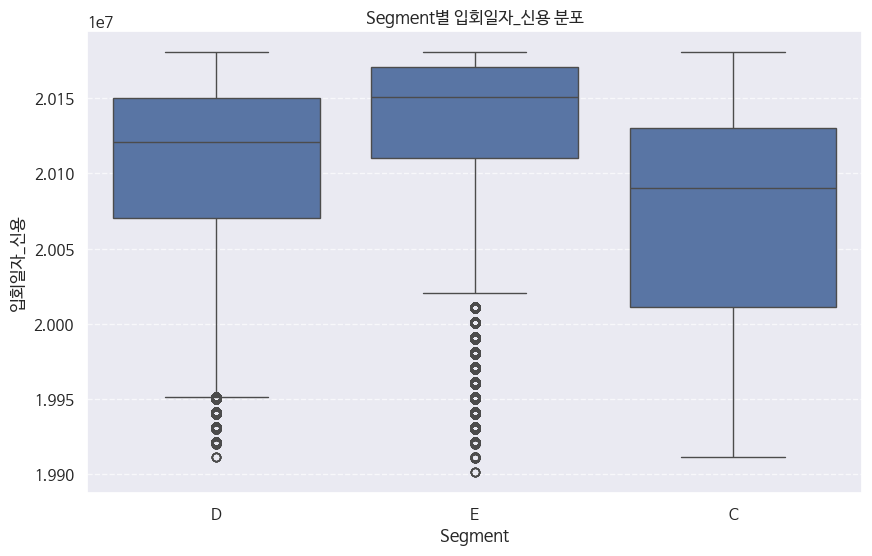

In [ ]:
plt.figure(figsize=(10, 6)) # 그래프 크기 설정
sns.boxplot(x='Segment', y='입회일자_신용', data=df)
plt.title('Segment별 입회일자_신용 분포')
plt.xlabel('Segment')
plt.ylabel('입회일자_신용')
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 그리드 추가
plt.show()

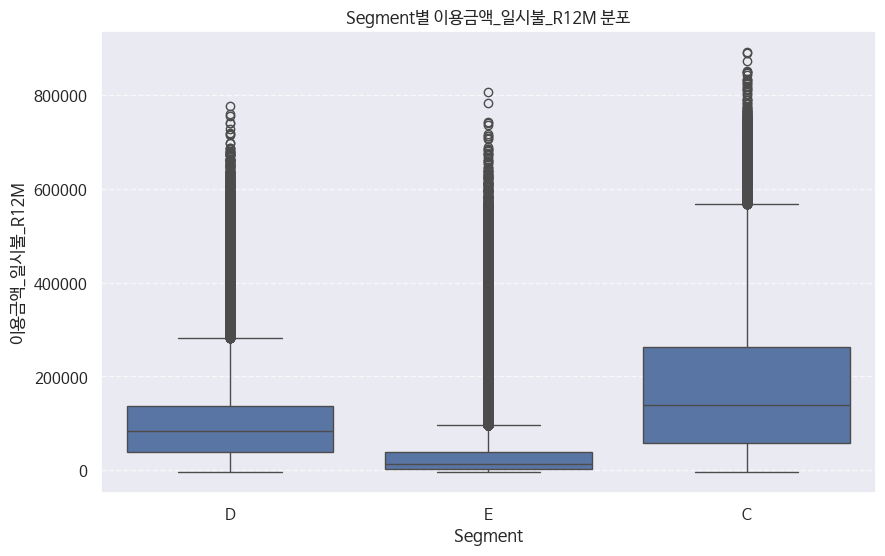

In [ ]:
plt.figure(figsize=(10, 6)) # 그래프 크기 설정
sns.boxplot(x='Segment', y='이용금액_일시불_R12M', data=df)
plt.title('Segment별 이용금액_일시불_R12M 분포')
plt.xlabel('Segment')
plt.ylabel('이용금액_일시불_R12M')
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 그리드 추가
plt.show()

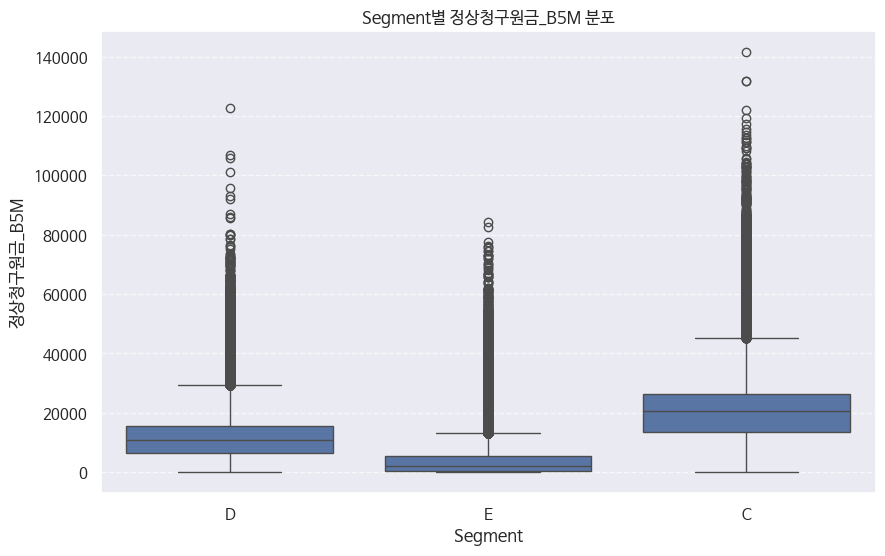

In [ ]:
plt.figure(figsize=(10, 6)) # 그래프 크기 설정
sns.boxplot(x='Segment', y='정상청구원금_B5M', data=df)
plt.title('Segment별 정상청구원금_B5M 분포')
plt.xlabel('Segment')
plt.ylabel('정상청구원금_B5M')
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 그리드 추가
plt.show()
